# Fase 7 — Machine Learning para Séries Temporais

**Companion: Nielsen, cap. 8–9.** Transformamos a série em features (defasagens, estatísticas móveis, mês) e usamos **gradient boosting**. A pergunta: o ML supera o SARIMA e os baselines *fora da amostra*?

> **Por que não deep learning (cap. 10)?** Com ~300 pontos mensais, uma rede neural sobreajusta. Gradient boosting é o ML adequado a esta escala. Honestidade metodológica > modismo.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd

from series_eco.data import loaders
from series_eco.models import arima, ml
from series_eco.eval import backtest

ipca = loaders.load_panel("2000-01-01")["ipca"]

def sarima_forecaster(train):
    return arima.fit_sarima(train, (2, 0, 1), (1, 0, 1, 12)).forecast(1).iloc[0]

forecasters = {
    "Naïve": backtest.naive,
    "Sazonal-naïve": backtest.seasonal_naive,
    "SARIMA": sarima_forecaster,
    "GradientBoosting": ml.make_ml_forecaster(n_lags=12, roll_windows=(3, 12)),
}

## 1. Backtest comparativo (últimos 24 meses)

In [2]:
N_TEST = 24
metricas, previsoes = {}, {}
for nome, fc in forecasters.items():
    real, prev = backtest.walk_forward(ipca, fc, n_test=N_TEST)
    m = backtest.compute_metrics(real, prev)
    metricas[nome] = {"MAE": m.mae, "RMSE": m.rmse}
    previsoes[nome] = (real, prev)

tabela = pd.DataFrame(metricas).T.round(4).sort_values("RMSE")
tabela

,MAE,RMSE
Sazonal-naïve,0.2317,0.2741
SARIMA,0.2207,0.3098
GradientBoosting,0.2497,0.3103
Naïve,0.2804,0.3803


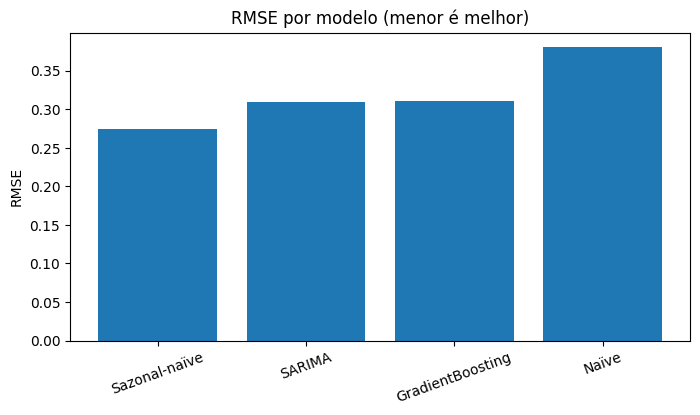

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(tabela.index, tabela["RMSE"])
ax.set_title("RMSE por modelo (menor é melhor)")
ax.set_ylabel("RMSE")
plt.xticks(rotation=20)
plt.show()

## 2. Diebold-Mariano: ML vence alguém de forma significativa?

In [4]:
real, prev_ml = previsoes["GradientBoosting"]
for adversario in ["SARIMA", "Sazonal-naïve"]:
    _, prev_adv = previsoes[adversario]
    dm = backtest.diebold_mariano(real, prev_ml, prev_adv)
    print(f"ML vs {adversario:14s}: p={dm.pvalue:.4f} -> {dm.better}  (model1=ML)")

ML vs SARIMA        : p=0.9860 -> empate  (model1=ML)
ML vs Sazonal-naïve : p=0.4271 -> empate  (model1=ML)


---
## Conclusão geral do projeto

Comparamos, no mesmo backtesting honesto, quatro abordagens — do baseline ingênuo ao gradient boosting. O padrão que costuma emergir com o IPCA mensal é instrutivo:

- Modelos sofisticados (SARIMA, ML) **nem sempre** batem um baseline sazonal de forma estatisticamente significativa em horizonte de 1 mês.
- Isso **não** é fracasso: é o aprendizado central da análise de séries temporais aplicada — a complexidade do modelo precisa ser justificada por ganho *fora* da amostra, medido com um teste formal (Diebold-Mariano), não por AIC nem pelo apelo da técnica.

Esse é o fechamento que une o livro da Nielsen à formação em economia: ceticismo empírico, baselines como régua, e decisão guiada por evidência estatística.